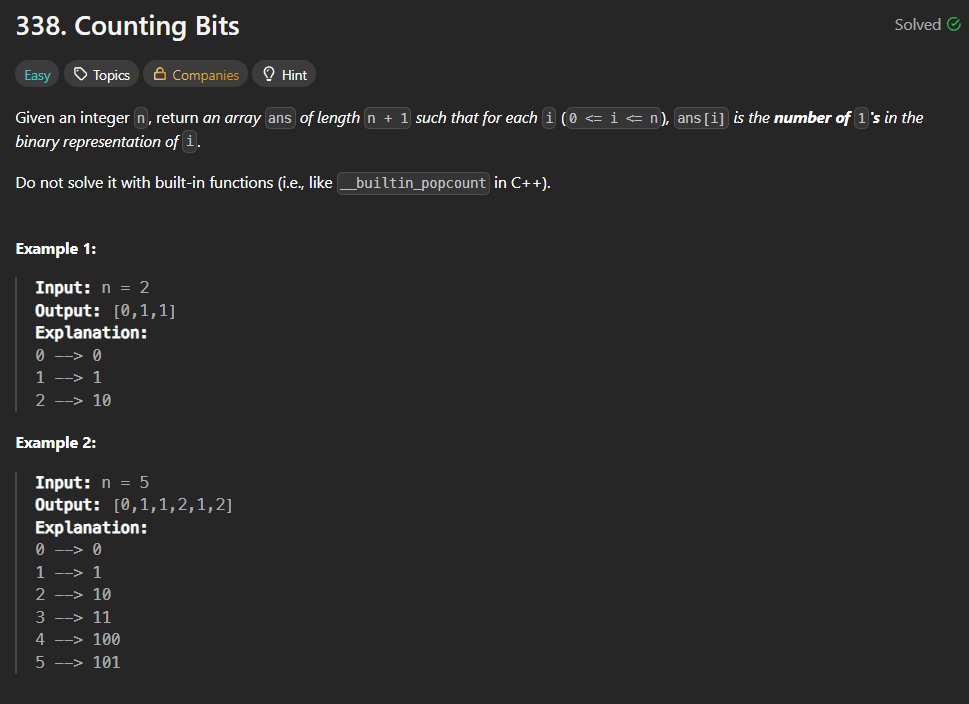

***Brute Force Approach***

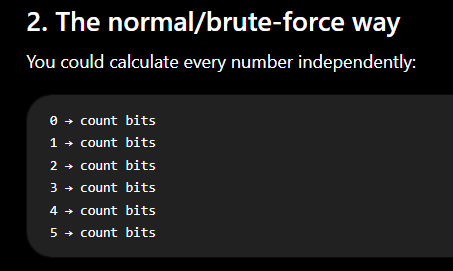

In [ ]:
from typing import List

class Solution:
  def countBits(self , n : int) -> List[int]:
    res = []
    count = 0

    for i in range(0 , n + 1):
      for j in range(i.bit_length()):
        if (i & 1) == 1:
          count = count + 1
        i = i >> 1
      res.append(count)
      count = 0

    return res

s = Solution()

In [ ]:
print(s.countBits(n = 5))

[0, 1, 1, 2, 1, 2]


***Optimized Approach*** - using Dynamic Programming

### Explanation of the Optimized DP Approach

This approach uses **Dynamic Programming** to solve the problem in $O(n)$ time by building on previously calculated results.

#### The Core Logic
The line `ans[i] = ans[i >> 1] + (i & 1)` relies on two observations:

1.  **`i >> 1` (Right Shift):** Shifting a number one bit to the right is the same as integer division by 2 (`i // 2`). The number of set bits in `i` is almost identical to the number of set bits in `i // 2`, because `i // 2` is simply the binary representation of `i` with the last digit removed.
2.  **`i & 1` (Bitwise AND):** This operation checks the last bit. If the number is odd, the last bit is `1`; if even, it's `0`.

#### Why it works:
To find the number of 1s in `i`, we look at the result we already calculated for `i // 2` and simply add `1` if `i` is odd. This prevents us from re-counting bits for every single number, making the algorithm significantly faster than the brute force method.

### Line-by-Line Breakdown

Let's analyze the logic in the cell containing your `OptmizedSol` class:

1.  **`ans = [0] * (n + 1)`**
    *   **What it does:** Creates a list of size `n + 1` filled with zeros.
    *   **Why:** We need to store a count for every number from `0` up to and including `n`. Since lists are 0-indexed, `n + 1` ensures `ans[n]` is a valid position.

2.  **`for i in range(n):`**
    *   **What it does:** Starts a loop that iterates through numbers.
    *   **A question for you:** Notice the current range goes up to `n-1`. If you want to include the number `n` in your result, how might you need to adjust this range?

3.  **`ans[i] = ans[i >> 1] + (i & 1)`**
    *   **`i >> 1`:** This is the "DP" part. It looks at a value we already calculated. If you remove the last bit of a number (by shifting it right), you get a smaller number you've already processed.
    *   **`i & 1`:** This checks if the bit we just "ignored" was a `1` or a `0`.
    *   **Combined:** We take the count of 1s from the smaller version of the number and add `1` if the current number is odd.

4.  **`return ans`**
    *   **What it does:** Returns the completed list of counts after the loop finishes.

In [8]:
from typing import List

class OptimizedSol:
  def countBits(self , n : int) -> List[int]:
    ans = [0] * (n + 1)

    for i in range(n + 1):   # goes till 0 to n ==> that's what we want
      ans[i] = ans[i >> 1] + (i & 1)
    return ans

s = OptimizedSol()

In [9]:
print(s.countBits(n = 5))

[0, 1, 1, 2, 1, 2]
